## Air Quality Index (AQI) — Time Series Analysis

This notebook queries the accumulated AQI readings from Neo4j and produces a series of charts exploring how air quality varies over time across the Pyrenees corridor. Each time the ingestion notebook is run, a new Reading node is appended per city — the more runs, the richer the time series.

### Before running the notebook

Export the following in your terminal:

```bash
export NEO4J_URI=bolt://127.0.0.1:7687
export NEO4J_USERNAME=your_username_here
export NEO4J_PASSWORD=your_password_here
export NEO4J_DATABASE=your_database_name_here
```

### Install and Load Packages

In [1]:
suppressMessages(install.packages(
  c("ggplot2", "httr2", "knitr"),
  quiet = TRUE
))

cat("Install complete.\n")

Install complete.


In [2]:
suppressMessages({
  library(ggplot2)
  library(httr2)
  library(knitr)
})

### Connection Settings

In [3]:
host     <- gsub("bolt://", "http://", Sys.getenv("NEO4J_URI"), fixed = TRUE)
host     <- gsub(":7687", ":7474", host, fixed = TRUE)
user     <- Sys.getenv("NEO4J_USERNAME")
password <- Sys.getenv("NEO4J_PASSWORD")
db       <- Sys.getenv("NEO4J_DATABASE")

cat("Credentials set.\n")

Credentials set.


### Query Helper Function

In [4]:
neo4j_query <- function(cypher) {
  response <- request(paste0(host, "/db/", db, "/query/v2")) |>
    req_auth_basic(user, password) |>
    req_headers(
      "Content-Type" = "application/json",
      "Accept"       = "application/json"
    ) |>
    req_body_json(list("statement" = cypher)) |>
    req_perform()

  json   <- resp_body_json(response, simplifyVector = TRUE)
  fields <- json$data$fields
  vals   <- json$data$values

  if (is.matrix(vals)) {
    values <- as.data.frame(vals)
  } else {
    values <- as.data.frame(do.call(rbind, lapply(vals, function(row) {
      as.data.frame(t(unlist(row)), stringsAsFactors = FALSE)
    })))
  }

  colnames(values) <- fields
  values <- type.convert(values, as.is = TRUE)
  values
}

### AQI Color Scale Helper

In [5]:
# Standard US AQI color scale — used consistently across all charts
aqi_color <- function(aqi) {
  ifelse(aqi <= 50,  "#00E400",
  ifelse(aqi <= 100, "#FFFF00",
  ifelse(aqi <= 150, "#FF7E00",
  ifelse(aqi <= 200, "#FF0000",
  ifelse(aqi <= 300, "#8F3F97",
                     "#7E0023")))))
}

aqi_category <- function(aqi) {
  ifelse(aqi <= 50,  "Good",
  ifelse(aqi <= 100, "Moderate",
  ifelse(aqi <= 150, "Unhealthy for Sensitive Groups",
  ifelse(aqi <= 200, "Unhealthy",
  ifelse(aqi <= 300, "Very Unhealthy",
                     "Hazardous")))))
}

### Chart 1: AQI Over Time — Top Cities by Average AQI

We plot AQI readings over time for the top 15 cities by average AQI. Each point represents a single reading; lines connect readings for the same city. This shows both the level and trend of air quality across the corridor.

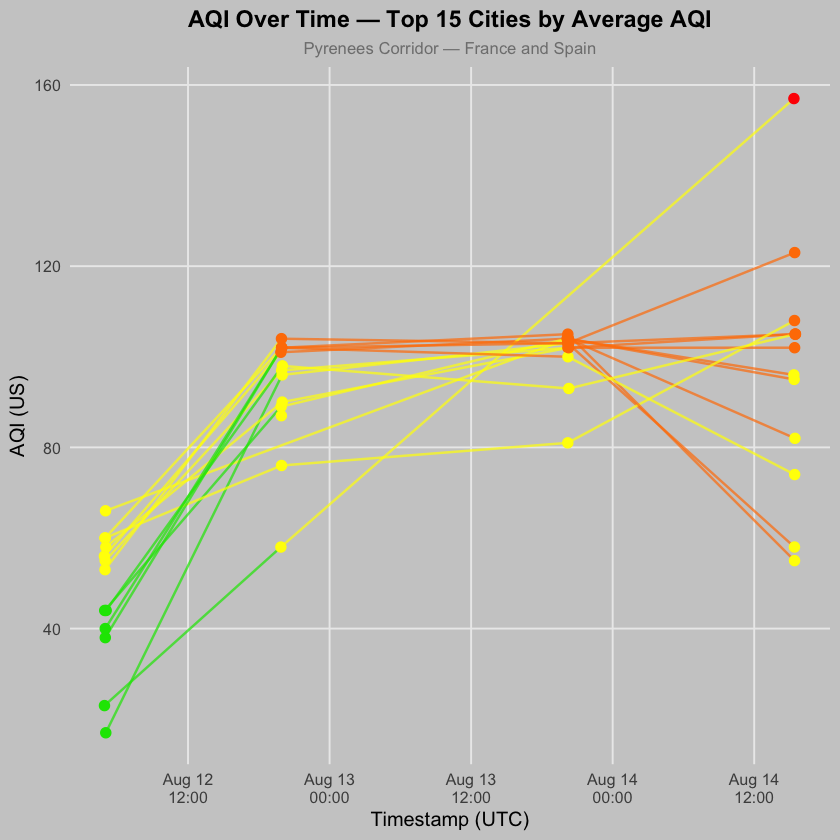

In [6]:
ts_data <- neo4j_query("
  MATCH (c:City)-[:HAS_READING]->(r:Reading)
  RETURN c.name      AS city,
         c.country   AS country,
         r.timestamp AS timestamp,
         r.aqi_us    AS aqi_us
  ORDER BY r.timestamp
")

# Keep top 15 cities by average AQI
top_cities <- aggregate(aqi_us ~ city, data = ts_data, FUN = mean)
top_cities <- top_cities[order(-top_cities$aqi_us), ][1:15, "city"]
ts_top     <- ts_data[ts_data$city %in% top_cities, ]

# Parse timestamp to datetime
ts_top$timestamp <- as.POSIXct(ts_top$timestamp,
                               format = "%Y-%m-%dT%H:%M:%S",
                               tz = "UTC")
ts_top$color <- aqi_color(ts_top$aqi_us)

ggplot(ts_top, aes(x = timestamp, y = aqi_us, group = city, color = color)) +
  geom_line(linewidth = 0.7, alpha = 0.7) +
  geom_point(size = 2.5, aes(color = color)) +
  scale_color_identity() +
  scale_x_datetime(date_labels = "%b %d\n%H:%M") +
  labs(
    title    = "AQI Over Time — Top 15 Cities by Average AQI",
    subtitle = "Pyrenees Corridor — France and Spain",
    x        = "Timestamp (UTC)",
    y        = "AQI (US)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title       = element_text(face = "bold", size = 14, hjust = 0.5),
    plot.subtitle    = element_text(size = 10, hjust = 0.5, color = "grey50"),
    plot.background  = element_rect(fill = "#CCCCCC", color = NA),
    panel.background = element_rect(fill = "#CCCCCC", color = NA),
    panel.grid.minor = element_blank(),
    legend.position  = "none"
  )

### Chart 2: AQI Heatmap — Cities vs Timestamps

Each row is one of the 30 cities with the highest average AQI, each column is a reading date, and the fill color follows the standard AQI scale. Cities are ordered so the worst appear at the top. This gives a focused view of the most polluted part of the corridor — showing both the overall level and how AQI shifts between readings for each city.

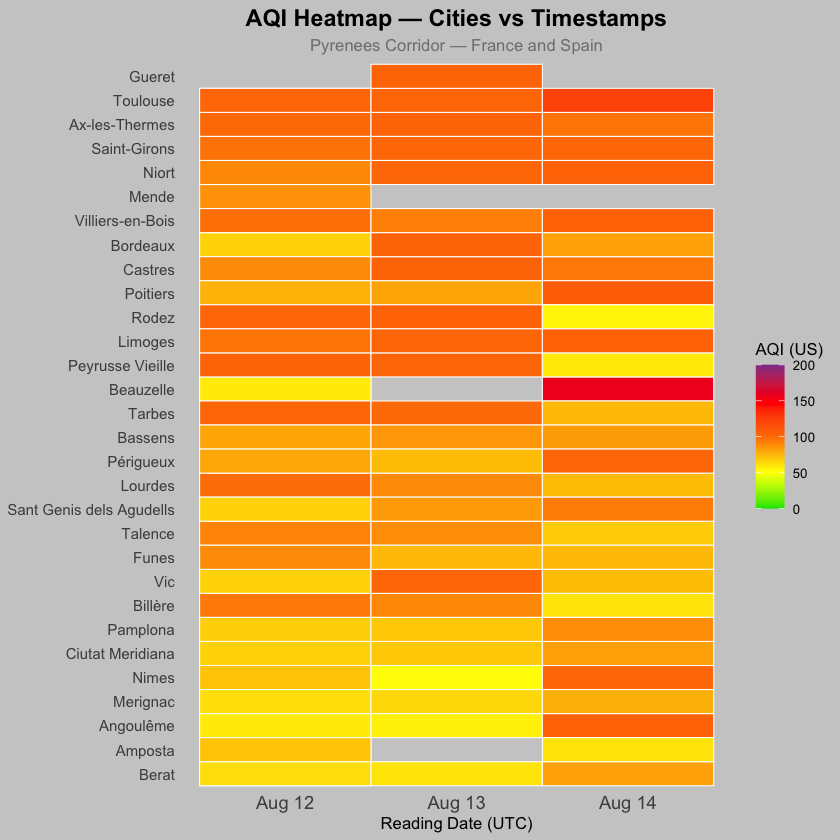

In [7]:
heatmap_data <- neo4j_query("
  MATCH (c:City)-[:HAS_READING]->(r:Reading)
  RETURN c.name    AS city,
         c.country AS country,
         r.timestamp AS timestamp,
         r.aqi_us    AS aqi_us
  ORDER BY r.timestamp
")

heatmap_data$timestamp <- as.POSIXct(heatmap_data$timestamp,
                                     format = "%Y-%m-%dT%H:%M:%S",
                                     tz = "UTC")

# Order cities by average AQI descending, keep top 30
city_order <- aggregate(aqi_us ~ city, data = heatmap_data, FUN = mean)
city_order <- city_order[order(-city_order$aqi_us), "city"]
top30      <- city_order[1:30]
heatmap_data <- heatmap_data[heatmap_data$city %in% top30, ]
heatmap_data$city <- factor(heatmap_data$city, levels = rev(top30))

# Date-only label
heatmap_data$time_label <- format(heatmap_data$timestamp, "%b %d")

ggplot(heatmap_data, aes(x = time_label, y = city, fill = aqi_us)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_gradientn(
    colors = c("#00E400", "#FFFF00", "#FF7E00", "#FF0000", "#8F3F97"),
    values  = scales::rescale(c(0, 50, 100, 150, 200)),
    limits  = c(0, 200),
    name    = "AQI (US)"
  ) +
  labs(
    title    = "AQI Heatmap — Cities vs Timestamps",
    subtitle = "Pyrenees Corridor — France and Spain",
    x        = "Reading Date (UTC)",
    y        = NULL
  ) +
  theme_minimal(base_size = 10) +
  theme(
    plot.title       = element_text(face = "bold", size = 14, hjust = 0.5),
    plot.subtitle    = element_text(size = 10, hjust = 0.5, color = "grey50"),
    plot.background  = element_rect(fill = "#CCCCCC", color = NA),
    panel.background = element_rect(fill = "#CCCCCC", color = NA),
    axis.text.y      = element_text(size = 9),
    axis.text.x      = element_text(size = 11),
    panel.grid       = element_blank(),
    legend.position  = "right"
  )

### Chart 3: AQI vs Temperature

Each point represents a single reading — one city at one timestamp. AQI is on the y-axis and temperature in degrees Celsius on the x-axis. Points are colored by country with a LOESS smooth trend line fitted separately for France and Spain. This explores whether warmer conditions are associated with higher AQI values across the corridor.

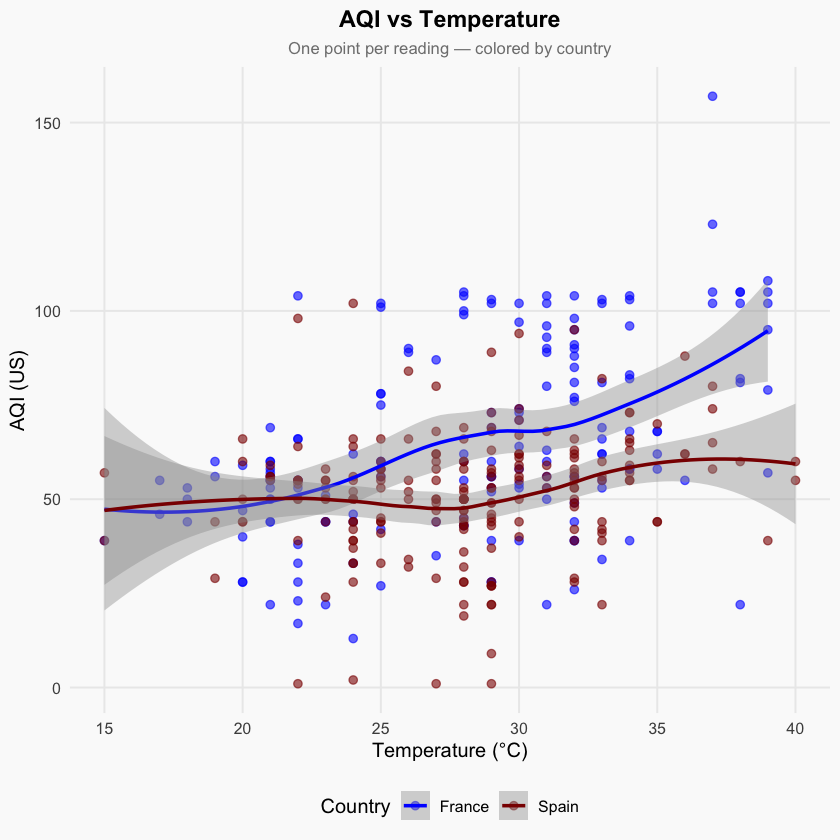

In [8]:
scatter_data <- neo4j_query("
  MATCH (c:City)-[:HAS_READING]->(r:Reading)
  WHERE r.temperature IS NOT NULL
  RETURN c.name       AS city,
         c.country    AS country,
         r.aqi_us     AS aqi_us,
         r.temperature AS temperature,
         r.humidity   AS humidity
")

ggplot(scatter_data, aes(x = temperature, y = aqi_us, color = country)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_smooth(method = "loess", formula = y ~ x, se = TRUE, linewidth = 1) +
  scale_color_manual(
    values = c("France" = "#0000FF", "Spain" = "#8B0000"),
    name   = "Country"
  ) +
  labs(
    title    = "AQI vs Temperature",
    subtitle = "One point per reading — colored by country",
    x        = "Temperature (°C)",
    y        = "AQI (US)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title       = element_text(face = "bold", size = 14, hjust = 0.5),
    plot.subtitle    = element_text(size = 10, hjust = 0.5, color = "grey50"),
    plot.background  = element_rect(fill = "#FAFAFA", color = NA),
    panel.background = element_rect(fill = "#FAFAFA", color = NA),
    panel.grid.minor = element_blank(),
    legend.position  = "bottom"
  )

### Chart 4: AQI Distribution per City

Box plots show the spread of AQI values across all readings for each city. A wide box indicates high variability between readings; a narrow box indicates consistency. Cities are ordered by median AQI and colored by country. This reveals which cities are reliably good or bad and which are unpredictable.

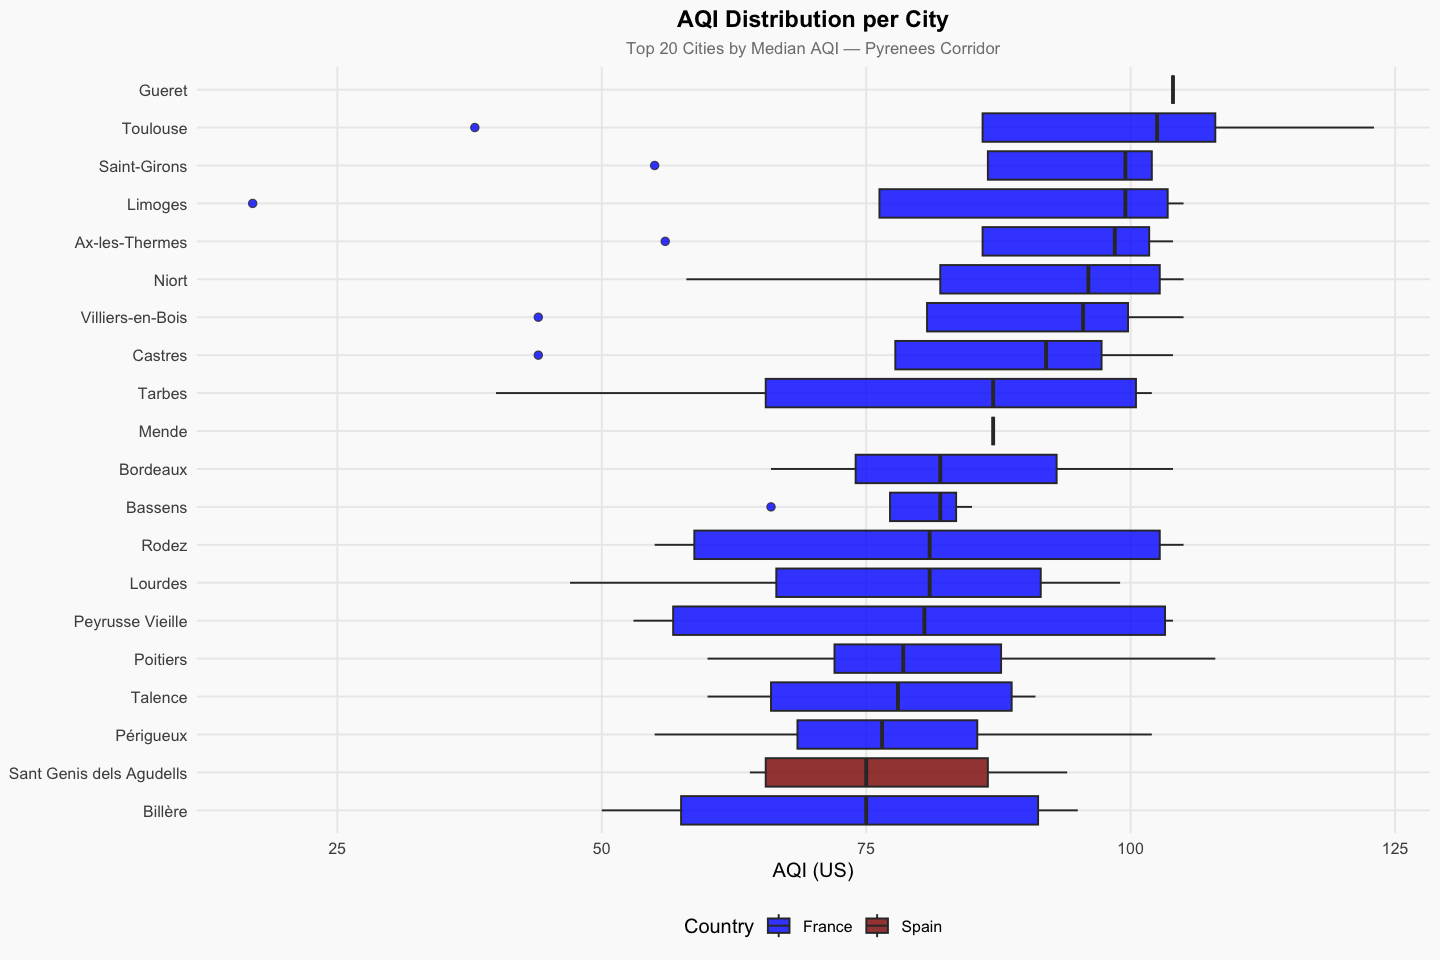

In [9]:
options(repr.plot.width = 12, repr.plot.height = 8)

box_data <- neo4j_query("
  MATCH (c:City)-[:HAS_READING]->(r:Reading)
  RETURN c.name    AS city,
         c.country AS country,
         r.aqi_us  AS aqi_us
")

# Keep top 20 cities by median AQI
city_median <- aggregate(aqi_us ~ city, data = box_data, FUN = median)
top20 <- city_median[order(-city_median$aqi_us), "city"][1:20]
box_data <- box_data[box_data$city %in% top20, ]
box_data$city <- factor(box_data$city,
                        levels = city_median[order(city_median$aqi_us), "city"])

suppressMessages(print(
  ggplot(box_data, aes(x = city, y = aqi_us, fill = country)) +
    geom_boxplot(alpha = 0.8, outlier.shape = 21, outlier.size = 2) +
    scale_fill_manual(
      values = c("France" = "#0000FF", "Spain" = "#8B0000"),
      name   = "Country"
    ) +
    coord_flip() +
    labs(
      title    = "AQI Distribution per City",
      subtitle = "Top 20 Cities by Median AQI — Pyrenees Corridor",
      x        = NULL,
      y        = "AQI (US)"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title       = element_text(face = "bold", size = 14, hjust = 0.5),
      plot.subtitle    = element_text(size = 10, hjust = 0.5, color = "grey50"),
      plot.background  = element_rect(fill = "#FAFAFA", color = NA),
      panel.background = element_rect(fill = "#FAFAFA", color = NA),
      panel.grid.minor = element_blank(),
      legend.position  = "bottom"
    )
))

### Chart 5: Most Improved vs Most Worsened Cities

This chart compares the top 10 cities that improved most against the top 10 that worsened most between their first and latest reading. Green bars show improvement; red bars show deterioration. The contrast in scale between the two panels is itself informative — modest improvements on the left, dramatic deteriorations on the right.

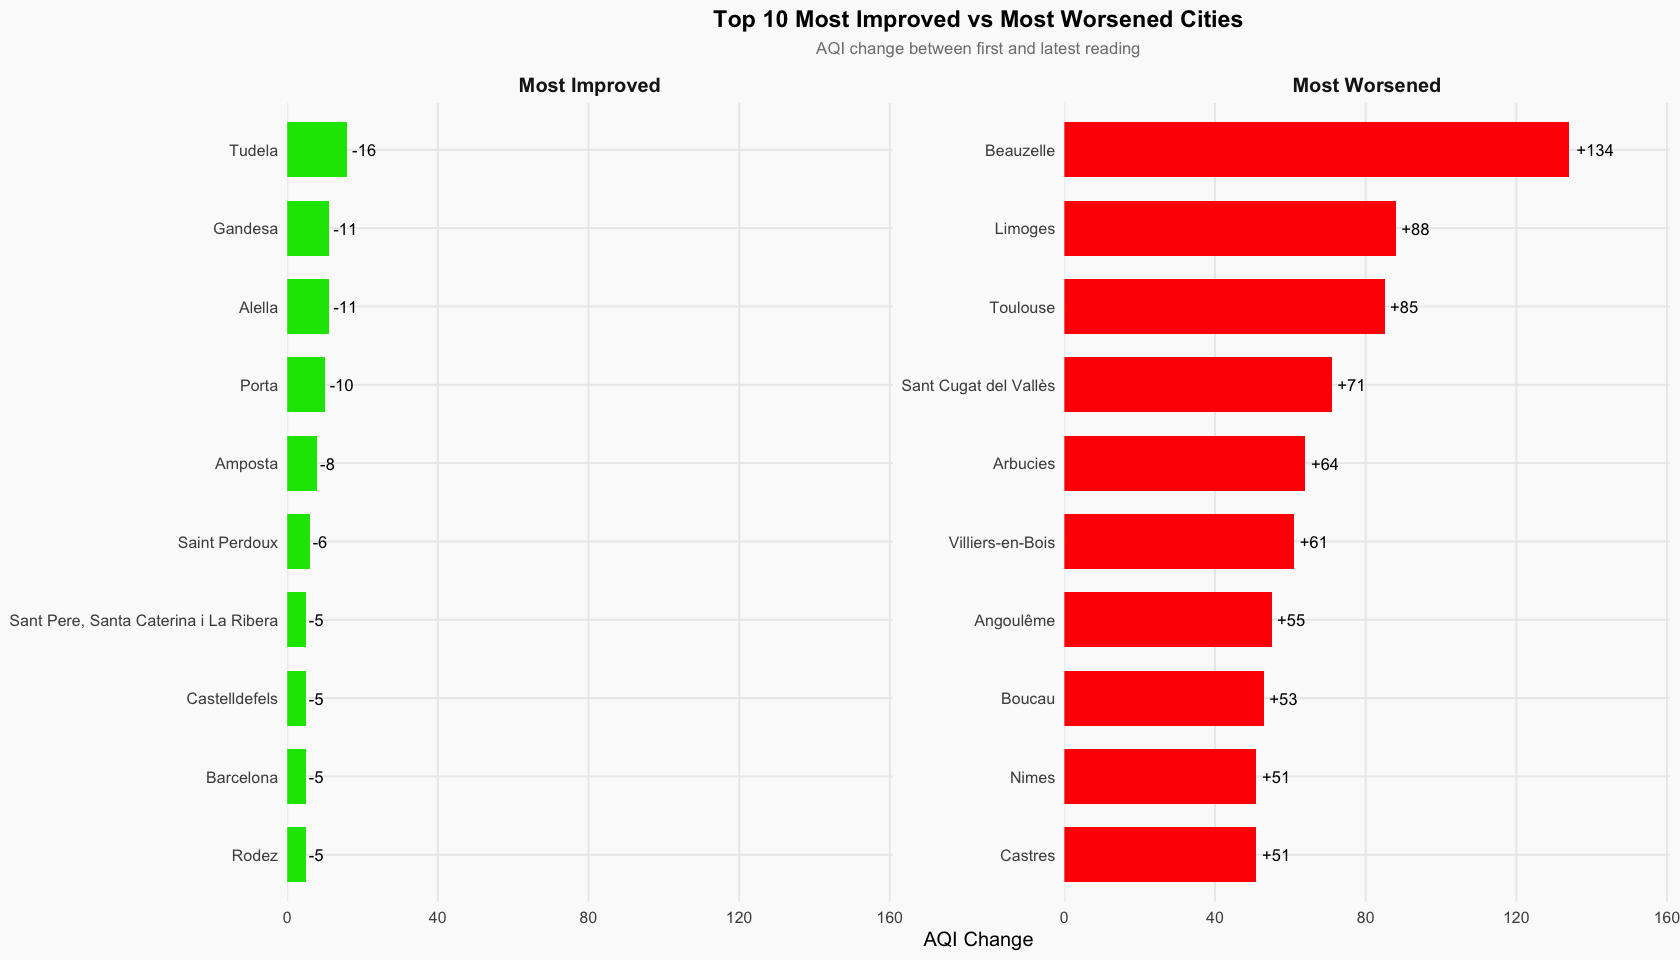

In [10]:
options(repr.plot.width = 14, repr.plot.height = 8)

change_data <- neo4j_query("
  MATCH (c:City)-[:HAS_READING]->(r:Reading)
  WITH c, r ORDER BY r.timestamp
  WITH c, collect(r) AS readings
  WHERE size(readings) > 1
  RETURN c.name    AS city,
         c.country AS country,
         readings[0].aqi_us  AS first_aqi,
         readings[-1].aqi_us AS latest_aqi,
         readings[-1].aqi_us - readings[0].aqi_us AS change
")

improved <- change_data[change_data$change < 0, ]
improved <- improved[order(improved$change), ][1:min(10, nrow(improved)), ]
improved$direction <- "Most Improved"
improved$bar_value <- abs(improved$change)
improved$city <- factor(improved$city, levels = improved$city[order(abs(improved$change))])

worsened <- change_data[change_data$change > 0, ]
worsened <- worsened[order(-worsened$change), ][1:min(10, nrow(worsened)), ]
worsened$direction <- "Most Worsened"
worsened$bar_value <- worsened$change
worsened$city <- factor(worsened$city, levels = worsened$city[order(worsened$change)])

combined <- rbind(improved, worsened)
combined$bar_color <- ifelse(combined$direction == "Most Improved", "#00E400", "#FF0000")
combined$label     <- ifelse(combined$direction == "Most Improved",
                             paste0("-", combined$bar_value),
                             paste0("+", combined$bar_value))

suppressMessages(print(
  ggplot(combined, aes(x = city, y = bar_value, fill = bar_color)) +
    geom_col(width = 0.7) +
    geom_text(aes(label = label), hjust = -0.2, size = 3.5) +
    scale_fill_identity() +
    scale_y_continuous(expand = expansion(mult = c(0, 0.2))) +
    coord_flip() +
    facet_wrap(~ direction, scales = "free_y") +
    labs(
      title    = "Top 10 Most Improved vs Most Worsened Cities",
      subtitle = "AQI change between first and latest reading",
      x        = NULL,
      y        = "AQI Change"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title       = element_text(face = "bold", size = 14, hjust = 0.5),
      plot.subtitle    = element_text(size = 10, hjust = 0.5, color = "grey50"),
      plot.background  = element_rect(fill = "#FAFAFA", color = NA),
      panel.background = element_rect(fill = "#FAFAFA", color = NA),
      panel.grid.minor = element_blank(),
      strip.text       = element_text(face = "bold", size = 12),
      legend.position  = "none"
    )
))